# Predictive Maintenance for Industrial Equipment Failure

## Exploratory Data Analysis (EDA) and Model Evaluation

**Project Type:** Binary Classification  
**Dataset:** Predictive Maintenance Dataset  
**Prepared by:** Amna Bibi  
**Team:** Baby Seven  
**Role:** Exploratory Data Analysis & Model Evaluation

---

### Project Objective

The objective of this project is to develop a predictive maintenance system that can identify whether an industrial equipment observation is associated with a machine failure.

The project follows a data science workflow consisting of:

1. Data loading and understanding
2. Data quality assessment
3. Exploratory Data Analysis (EDA)
4. Data preprocessing
5. Feature engineering
6. Machine learning classification
7. Model evaluation
8. Dashboard and deployment

This notebook focuses primarily on **Exploratory Data Analysis and Model Evaluation**.

## 1. Importing Required Libraries

The following Python libraries are used for data manipulation, numerical analysis, visualization, and statistical exploration.

- **Pandas:** Data loading, manipulation, and analysis
- **NumPy:** Numerical computations
- **Matplotlib:** Data visualization
- **Seaborn:** Statistical visualization
- **Warnings:** Suppression of non-critical warnings

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Dataset

The cleaned predictive maintenance dataset prepared by the project team is loaded for exploratory analysis.

The dataset contains time information, equipment/device identifiers, a binary failure indicator, and multiple sensor measurements.

The target variable for the classification problem is:

- `failure = 0`: No failure
- `failure = 1`: Failure

In [39]:
df = pd.read_csv("C:\\Users\\khan\\Desktop\\house price prediction\\Predictive-Maintenance-for-Industrial-Equipment-Failure-Classification-\\data\\cleaned_predictive_maintenance_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (20250, 12)


,date,device,failure,Air_Temp_K,Process_Temp_K,Rotational_Speed,Torque,Tool_Wear,Pressure,Vibration,Voltage,Current
0,2015-01-01,M3RGW8ZX,0,299.79,308.92,1508.4,25.87,11.0,105.67,0.939,225.29,9.79
1,2015-01-01,P0XB2ZEW,0,299.93,307.68,1784.5,30.94,5.3,101.52,0.587,230.93,8.16
2,2015-01-01,P0XDS15G,0,300.02,308.31,1936.0,34.64,6.5,107.19,1.178,238.04,16.31
3,2015-01-01,P0XGEX5J,0,300.45,308.98,1594.3,32.21,2.7,103.23,1.346,225.69,14.23
4,2015-01-01,R7Q05794,0,301.43,310.15,1450.3,42.16,4.0,106.82,1.039,239.90,12.38


## 3. Dataset Overview

Before performing statistical analysis, it is important to understand the structure and dimensions of the dataset.

The following analysis examines:

- Number of observations
- Number of variables
- Variable names
- Data types
- Initial records
- Summary statistics

Understanding the dataset structure helps identify suitable preprocessing and analysis techniques.

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 20250
Number of columns: 12

Column names:
['date', 'device', 'failure', 'Air_Temp_K', 'Process_Temp_K', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Pressure', 'Vibration', 'Voltage', 'Current']


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20250 entries, 0 to 20249
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              20250 non-null  str    
 1   device            20250 non-null  str    
 2   failure           20250 non-null  int64  
 3   Air_Temp_K        20250 non-null  float64
 4   Process_Temp_K    20250 non-null  float64
 5   Rotational_Speed  20250 non-null  float64
 6   Torque            20250 non-null  float64
 7   Tool_Wear         20250 non-null  float64
 8   Pressure          20250 non-null  float64
 9   Vibration         20250 non-null  float64
 10  Voltage           20250 non-null  float64
 11  Current           20250 non-null  float64
dtypes: float64(9), int64(1), str(2)
memory usage: 1.9 MB


In [10]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,20250,731,2016-03-13,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,20250,72,M3RQ3ASU,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
failure,20250.0,NaN,NaN,NaN,0.086025,0.280407,0.0,0.0,0.0,0.0,1.0
Air_Temp_K,20250.0,NaN,NaN,NaN,299.454145,1.590084,295.0,298.41,299.44,300.47,305.0
Process_Temp_K,20250.0,NaN,NaN,NaN,307.682695,1.816024,305.0,306.31,307.56,308.88,315.0
Rotational_Speed,20250.0,NaN,NaN,NaN,1737.089822,139.553613,1115.9,1646.3,1736.0,1827.2,2496.1
Torque,20250.0,NaN,NaN,NaN,36.08735,16.223153,5.0,25.2,35.04,45.25,80.0
Tool_Wear,20250.0,NaN,NaN,NaN,52.711598,28.437949,0.6,29.4,50.6,73.0,131.8
Pressure,20250.0,NaN,NaN,NaN,104.905654,3.220461,90.94,102.74,104.91,107.0,117.95
Vibration,20250.0,NaN,NaN,NaN,1.838891,0.985789,0.2,1.205,1.683,2.237,7.477


The sensor variables are retained using the project-defined feature names. Their numerical distributions are analyzed in the recorded scale without applying additional physical-unit assumptions."

## 4. Data Types

Examining data types is an important preprocessing and EDA step.

Numerical variables can be analyzed using statistical measures and numerical visualizations, while categorical variables require different analytical techniques.

The `date` variable will be converted into a datetime format to enable time-based analysis.

In [11]:
df.dtypes

date                    str
device                  str
failure               int64
Air_Temp_K          float64
Process_Temp_K      float64
Rotational_Speed    float64
Torque              float64
Tool_Wear           float64
Pressure            float64
Vibration           float64
Voltage             float64
Current             float64
dtype: object

### Data Quality Analysis

##  Missing Value Analysis

Missing values can affect statistical analysis and machine learning performance.

The number and percentage of missing observations are therefore examined for each variable.

If missing values are present, their treatment should be documented in the preprocessing stage.

In [12]:
print("=== DATA QUALITY ANALYSIS ===")

print("\nMissing Values:")
display(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

=== DATA QUALITY ANALYSIS ===

Missing Values:


date                0
device              0
failure             0
Air_Temp_K          0
Process_Temp_K      0
Rotational_Speed    0
Torque              0
Tool_Wear           0
Pressure            0
Vibration           0
Voltage             0
Current             0
dtype: int64


Total Missing Values:
0

Duplicate Rows:
0

Data Types:
date                    str
device                  str
failure               int64
Air_Temp_K          float64
Process_Temp_K      float64
Rotational_Speed    float64
Torque              float64
Tool_Wear           float64
Pressure            float64
Vibration           float64
Voltage             float64
Current             float64
dtype: object


##  Unique Value Analysis

The number of unique values in each variable is examined to understand the nature of the dataset and identify identifier-like variables or variables with limited categories.

In [13]:
print("=== UNIQUE VALUES ===")

unique_counts = df.nunique().sort_values()

display(unique_counts)

=== UNIQUE VALUES ===


failure                2
device                72
date                 731
Process_Temp_K       882
Air_Temp_K           964
Tool_Wear           1278
Pressure            1803
Current             2184
Voltage             2430
Vibration           4125
Torque              5761
Rotational_Speed    5804
dtype: int64

## 5. Date and Time Processing

The dataset contains a `date` variable representing the observation date.

Converting this variable to datetime format allows us to investigate temporal patterns in equipment failures, including failure frequency over time.

In [14]:
print("=== DATE CONTINUITY ANALYSIS ===")

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by date
dates = df["date"].sort_values().drop_duplicates()

print("First Date:", dates.min())
print("Last Date:", dates.max())

print("Number of Unique Dates:", len(dates))

# Calculate gaps between consecutive calendar dates
date_gaps = dates.diff().dropna()

print("\nLargest Gap:")
print(date_gaps.max())

print("\nGap Distribution:")
print(date_gaps.value_counts().sort_index())

=== DATE CONTINUITY ANALYSIS ===
First Date: 2015-01-01 00:00:00
Last Date: 2016-12-31 00:00:00
Number of Unique Dates: 731

Largest Gap:
1 days 00:00:00

Gap Distribution:
date
1 days    730
Name: count, dtype: int64


In [15]:
print("=== MISSING CALENDAR DATES ===")

full_date_range = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

missing_dates = full_date_range.difference(dates)

print("Number of Missing Calendar Dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nMissing Dates:")
    for date in missing_dates:
        print(date.date())
else:
    print("✅ No calendar dates are missing.")

=== MISSING CALENDAR DATES ===
Number of Missing Calendar Dates: 0
✅ No calendar dates are missing.


In [16]:
print("=== DEVICE-LEVEL DATE GAP ANALYSIS ===")

device_dates = (
    df[["device", "date"]]
    .drop_duplicates()
    .sort_values(["device", "date"])
)

# Calculate gap between consecutive observations for each device
device_dates["gap_days"] = (
    device_dates.groupby("device")["date"]
    .diff()
    .dt.days
)

# Keep only gaps greater than 1 day
gaps = device_dates[device_dates["gap_days"] > 1]

print("Number of devices with gaps > 1 day:", gaps["device"].nunique())

print("Maximum device-level gap (days):", gaps["gap_days"].max())

print("\nDevice-level gap distribution:")
display(gaps["gap_days"].value_counts().sort_index())

=== DEVICE-LEVEL DATE GAP ANALYSIS ===
Number of devices with gaps > 1 day: 72
Maximum device-level gap (days): 29.0

Device-level gap distribution:


gap_days
2.0     4733
3.0     2764
4.0     1684
5.0      999
6.0      598
7.0      396
8.0      269
9.0      173
10.0     126
11.0      73
12.0      43
13.0      35
14.0      23
15.0      22
16.0      12
17.0       8
18.0      10
19.0       2
20.0       3
21.0       4
22.0       1
24.0       3
26.0       1
28.0       1
29.0       1
Name: count, dtype: int64

In [17]:
print("=== OBSERVATIONS PER DEVICE ===")

device_observations = df.groupby("device")["date"].nunique()

display(device_observations.describe())

print("\nMinimum observations for a device:",
      device_observations.min())

print("Maximum observations for a device:",
      device_observations.max())

=== OBSERVATIONS PER DEVICE ===


count     72.000000
mean     281.250000
std       65.258478
min      167.000000
25%      229.000000
50%      282.000000
75%      339.750000
max      381.000000
Name: date, dtype: float64


Minimum observations for a device: 167
Maximum observations for a device: 381


### Date Continuity and Gap Analysis

The `date` column was converted to datetime format and analyzed for temporal continuity.

The dataset spans from 2015-01-01 to 2016-12-31 and contains **no missing calendar dates** (731 unique dates covering the full range, with a maximum calendar-level gap of exactly 1 day between consecutive dates).

Device-level analysis shows that all 72 devices in the dataset have at least one observation gap greater than one day between their own consecutive records, with the largest device-level gap reaching 29 days. The number of observations per device ranges from 167 to 381 (mean ≈ 281, median 282).

Therefore, while the dataset is continuous at the calendar level, individual devices do not report strictly every day. Missing dates were not filled and sensor values were not interpolated or forward-filled, since gaps of this size should not be reconstructed without additional information that could distort the sensor-failure relationships.

The `date` column is retained as a datetime variable for temporal analysis and potential future feature engineering.

##  Target Variable Analysis

The target variable is `failure`, which represents whether an equipment failure occurred.

- `0` represents no failure.
- `1` represents failure.

Understanding the target distribution is essential because an imbalanced target can strongly affect classification model performance.

If failure observations are substantially fewer than non-failure observations, accuracy alone will not be a reliable measure of model performance.

In [18]:
print("=== FAILURE / TARGET ANALYSIS ===")

failure_counts = df["failure"].value_counts().sort_index()

print("Failure Counts:")
display(failure_counts)

print("\nFailure Percentages:")
failure_percentages = df["failure"].value_counts(normalize=True).sort_index() * 100
display(failure_percentages)

print("\nFailure Rate:")
print(f"{df['failure'].mean() * 100:.4f}%")

=== FAILURE / TARGET ANALYSIS ===
Failure Counts:


failure
0    18508
1     1742
Name: count, dtype: int64


Failure Percentages:


failure
0    91.397531
1     8.602469
Name: proportion, dtype: float64


Failure Rate:
8.6025%


In [19]:
print("=== DEVICE-LEVEL FAILURE ANALYSIS ===")

failure_devices = df.loc[df["failure"] == 1, "device"].nunique()
total_devices = df["device"].nunique()

print("Total Devices:", total_devices)
print("Devices with at least one failure:", failure_devices)

print(
    "Percentage of devices with failure:",
    f"{failure_devices / total_devices * 100:.2f}%"
)

=== DEVICE-LEVEL FAILURE ANALYSIS ===
Total Devices: 72
Devices with at least one failure: 70
Percentage of devices with failure: 97.22%


### Device-Level Failure Analysis

The dataset contains 20,250 observations from 72 unique devices, of which 1,742 observations (8.60%) are labeled as failures — a moderate, not extreme, class imbalance.

At the device level, 70 of the 72 devices (97.22%) experienced at least one recorded failure. This means failures are common across nearly the entire device population, rather than being concentrated in a small subset of devices.

This distinction is important when interpreting the dataset: the overall imbalance (8.6% of rows are failures) is driven by within-device dynamics — most devices operate normally most of the time but do eventually fail — rather than by a large population of devices that never fail.

In [20]:
print("=== FAILURES PER DEVICE ===")

failures_per_device = (
    df[df["failure"] == 1]
    .groupby("device")
    .size()
    .sort_values(ascending=False)
)

print("Number of devices with failures:", len(failures_per_device))

print("\nFailures per affected device:")
display(failures_per_device.describe())

=== FAILURES PER DEVICE ===
Number of devices with failures: 70

Failures per affected device:


count     70.000000
mean      24.885714
std       27.956251
min        1.000000
25%        6.250000
50%       14.500000
75%       28.500000
max      130.000000
dtype: float64

### Failures per Device

The failure records were grouped by device to determine whether individual devices experienced multiple recorded failures.

Among the 70 devices with at least one failure, the number of failure observations per device varies substantially: minimum 1, mean ≈ 24.9, median 14.5, and maximum 130. This means most affected devices recorded **multiple** failure events over time, and a handful of devices (up to 130 failure observations) account for a disproportionate share of all recorded failures.

This indicates that repeated failure events for the same device are common in this dataset. The 8.6% row-level failure rate reflects a mix of failure rarity at the observation level and a highly uneven distribution of failure counts across devices, rather than each device contributing exactly one isolated failure record.

Sensor cardinality & zero-value analysis

In [21]:
print("=== ZERO-VALUE ANALYSIS ===")

numeric_cols = df.select_dtypes(include=np.number).columns

zero_counts = (df[numeric_cols] == 0).sum()
zero_percentages = (df[numeric_cols] == 0).mean() * 100

zero_analysis = pd.DataFrame({
    "Zero_Count": zero_counts,
    "Zero_Percentage": zero_percentages
}).sort_values("Zero_Percentage", ascending=False)

display(zero_analysis)

=== ZERO-VALUE ANALYSIS ===


,Zero_Count,Zero_Percentage
failure,18508,91.397531
Air_Temp_K,0,0.000000
Process_Temp_K,0,0.000000
Rotational_Speed,0,0.000000
Torque,0,0.000000
Tool_Wear,0,0.000000
Pressure,0,0.000000
Vibration,0,0.000000
Voltage,0,0.000000
Current,0,0.000000


### Zero-Value Analysis

None of the nine sensor variables contain any zero values: every sensor shows a Zero_Percentage of 0.00% across the full dataset.

This means the sensors were recording continuously within their normal operating ranges throughout data collection, and there is no zero-inflation to account for in the distribution, skewness, or outlier analysis that follows. Zero-value handling is therefore not a relevant preprocessing consideration for this dataset.

In [22]:
print("=== ZERO VALUES BY FAILURE STATUS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

zero_by_failure = pd.DataFrame({
    "Normal_Zero_%": (df.loc[df["failure"] == 0, sensor_cols] == 0).mean() * 100,
    "Failure_Zero_%": (df.loc[df["failure"] == 1, sensor_cols] == 0).mean() * 100
})

display(zero_by_failure)

=== ZERO VALUES BY FAILURE STATUS ===


,Normal_Zero_%,Failure_Zero_%
Air_Temp_K,0.0,0.0
Process_Temp_K,0.0,0.0
Rotational_Speed,0.0,0.0
Torque,0.0,0.0
Tool_Wear,0.0,0.0
Pressure,0.0,0.0
Vibration,0.0,0.0
Voltage,0.0,0.0
Current,0.0,0.0


sensor distributions

=== SENSOR DISTRIBUTIONS ===


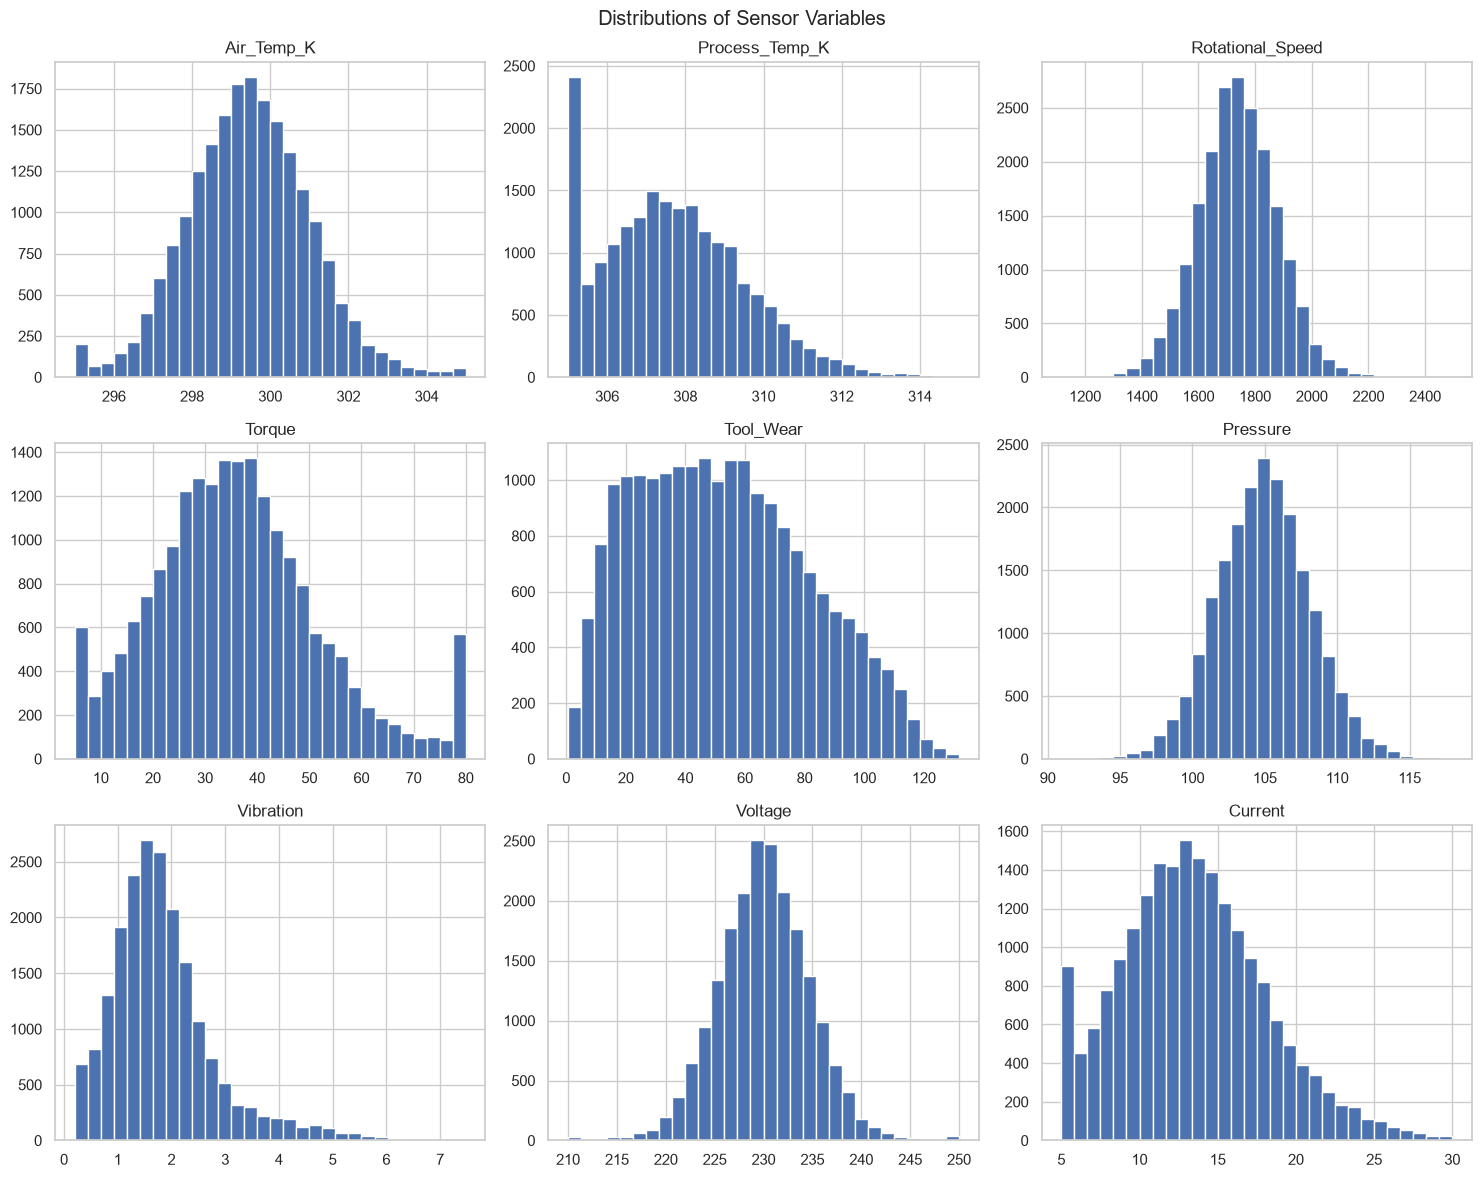

In [23]:
print("=== SENSOR DISTRIBUTIONS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

df[sensor_cols].hist(
    bins=30,
    figsize=(15, 12)
)

plt.suptitle("Distributions of Sensor Variables")
plt.tight_layout()
plt.show()

### Sensor Skewness Analysis

Skewness analysis shows that most sensor variables are only mildly skewed. Vibration has the highest skewness (≈1.38), indicating a moderate right skew, followed by Torque (≈0.52), Process_Temp_K (≈0.50), and Current (≈0.44). Tool_Wear is mildly right-skewed (≈0.32).

Air_Temp_K (≈0.09), Rotational_Speed (≈0.09), Pressure (≈0.04), and Voltage (≈0.03) are all approximately symmetric.

None of the variables show the extreme skewness that would typically accompany zero-inflation, which is consistent with the zero-value analysis above showing no zero readings in any sensor. No skewness-correcting transformation appears necessary based on this analysis alone; this will be revisited if a specific model requires it.

In [24]:
print("=== SENSOR SKEWNESS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

skewness = df[sensor_cols].skew().sort_values(ascending=False)

display(skewness.to_frame(name="Skewness"))

=== SENSOR SKEWNESS ===


,Skewness
Vibration,1.377140
Torque,0.521060
Process_Temp_K,0.500725
Current,0.436750
Tool_Wear,0.324889
Air_Temp_K,0.093515
Rotational_Speed,0.089240
Pressure,0.043505
Voltage,0.032989


### Outlier Analysis

The Interquartile Range (IQR) method was used to identify statistically extreme observations. Outlier rates are modest across all sensors, ranging from 0.00% (Tool_Wear, no outliers) up to about 5.24% (Vibration, the highest). Torque (3.22%), Air_Temp_K (1.99%), Rotational_Speed (1.36%), Voltage (1.59%), Current (1.23%), and Pressure (1.03%) all show low outlier rates, and Process_Temp_K is similarly low (0.78%).

Because no sensor is zero-inflated in this dataset, the IQR quartiles are well-behaved rather than collapsed at zero, so these percentages reflect genuine tail observations rather than an artifact of a degenerate distribution.

These observations were not removed, since they may represent legitimate extreme operating conditions that carry information relevant to failure detection. Further analysis compares sensor distributions between normal and failure observations before deciding on any preprocessing.

In [25]:
print("=== OUTLIER ANALYSIS (IQR METHOD) ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

outlier_results = []

for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Outlier_Percentage": outliers / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

=== OUTLIER ANALYSIS (IQR METHOD) ===


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Air_Temp_K,298.410,300.470,2.060,295.320,303.560,402,1.985185
1,Process_Temp_K,306.310,308.880,2.570,302.455,312.735,158,0.780247
2,Rotational_Speed,1646.300,1827.200,180.900,1374.950,2098.550,276,1.362963
3,Torque,25.200,45.250,20.050,-4.875,75.325,652,3.219753
4,Tool_Wear,29.400,73.000,43.600,-36.000,138.400,0,0.000000
5,Pressure,102.740,107.000,4.260,96.350,113.390,208,1.027160
6,Vibration,1.205,2.237,1.032,-0.343,3.785,1062,5.244444
7,Voltage,227.000,233.070,6.070,217.895,242.175,322,1.590123
8,Current,10.200,16.330,6.130,1.005,25.525,249,1.229630


### Sensor Zero-State and Failure Rate Analysis

Since none of the sensor variables contain any zero values in this dataset, a zero-vs-non-zero failure-rate comparison is not meaningful here: every observation falls in the "non-zero" group by definition, so the non-zero failure rate for every sensor simply equals the overall failure rate (8.60%), and the zero-group rate is undefined.

This check is retained for completeness but does not provide additional information for this dataset. The distributional comparison between normal and failure observations (below) is the more informative analysis here.

In [26]:
print("=== SENSOR STATISTICS BY FAILURE STATUS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

failure_stats = df.groupby("failure")[sensor_cols].agg(
    ["mean", "median", "min", "max"]
)

display(failure_stats)

=== SENSOR STATISTICS BY FAILURE STATUS ===


Air_Temp_K                       Process_Temp_K                 \
               mean  median    min    max           mean  median    min   
failure                                                                   
0        299.421859  299.43  295.0  305.0     307.580137  307.49  305.0   
1        299.797176  299.61  295.0  305.0     308.772331  308.61  305.0   

               Rotational_Speed          ... Vibration           Voltage  \
           max             mean  median  ...       min    max       mean   
failure                                  ...                               
0        315.0      1736.042217  1735.2  ...       0.2  6.641  230.05880   
1        315.0      1748.220178  1747.0  ...       0.2  7.477  229.89698   

                                 Current                    
         median    min    max       mean median  min   max  
failure                                                     
0        230.03  210.0  250.0  12.940282  12.84  5.0  30.0  
1        229.66  210.0  250.0  18.945962  19.14  5.0  30.0  

[2 rows x 36 columns]

In [27]:
print("=== FAILURE RATE: ZERO VS NON-ZERO SENSOR VALUES ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

zero_nonzero_results = []

for col in sensor_cols:
    
    zero_mask = df[col] == 0
    nonzero_mask = df[col] != 0
    
    zero_failure_rate = df.loc[zero_mask, "failure"].mean() * 100
    nonzero_failure_rate = df.loc[nonzero_mask, "failure"].mean() * 100
    
    zero_nonzero_results.append({
        "Feature": col,
        "Zero_Count": zero_mask.sum(),
        "Nonzero_Count": nonzero_mask.sum(),
        "Failure_Rate_Zero_%": zero_failure_rate,
        "Failure_Rate_Nonzero_%": nonzero_failure_rate
    })

zero_nonzero_df = pd.DataFrame(zero_nonzero_results)

display(zero_nonzero_df)

=== FAILURE RATE: ZERO VS NON-ZERO SENSOR VALUES ===


,Feature,Zero_Count,Nonzero_Count,Failure_Rate_Zero_%,Failure_Rate_Nonzero_%
0,Air_Temp_K,0,20250,NaN,8.602469
1,Process_Temp_K,0,20250,NaN,8.602469
2,Rotational_Speed,0,20250,NaN,8.602469
3,Torque,0,20250,NaN,8.602469
4,Tool_Wear,0,20250,NaN,8.602469
5,Pressure,0,20250,NaN,8.602469
6,Vibration,0,20250,NaN,8.602469
7,Voltage,0,20250,NaN,8.602469
8,Current,0,20250,NaN,8.602469


### Sensor Distributions by Failure Status

Sensor distributions were compared between normal and failure observations using summary statistics and boxplots.

Several sensors show a clear separation between classes:

- **Torque** shows the strongest separation: the median rises from 33.77 (normal) to 61.64 (failure), and the 75th percentile rises from 42.91 to 79.71 — close to the sensor's maximum of 80.0.
- **Vibration** median rises from 1.62 (normal) to 3.08 (failure), with the 75th percentile increasing from 2.12 to 4.42.
- **Current** median rises from 12.84 (normal) to 19.14 (failure).
- **Process_Temp_K** shows a smaller but consistent upward shift, with the median rising from 307.49 (normal) to 308.61 (failure).

Other sensors show weaker or negligible separation between classes:

- **Air_Temp_K**, **Pressure**, and **Voltage** show only small differences in median and quartiles between normal and failure observations.
- **Tool_Wear** shows a moderate increase (median 49.9 → 58.35).
- **Rotational_Speed** shows only a small shift (median 1735.2 → 1747.0).

These patterns line up with the correlation analysis below, where Vibration, Torque, and Current show the strongest positive linear association with failure. These findings are exploratory pending model-level validation, but the separation is visible even from raw quartile comparisons.

=== SENSOR VALUES BY FAILURE STATUS ===


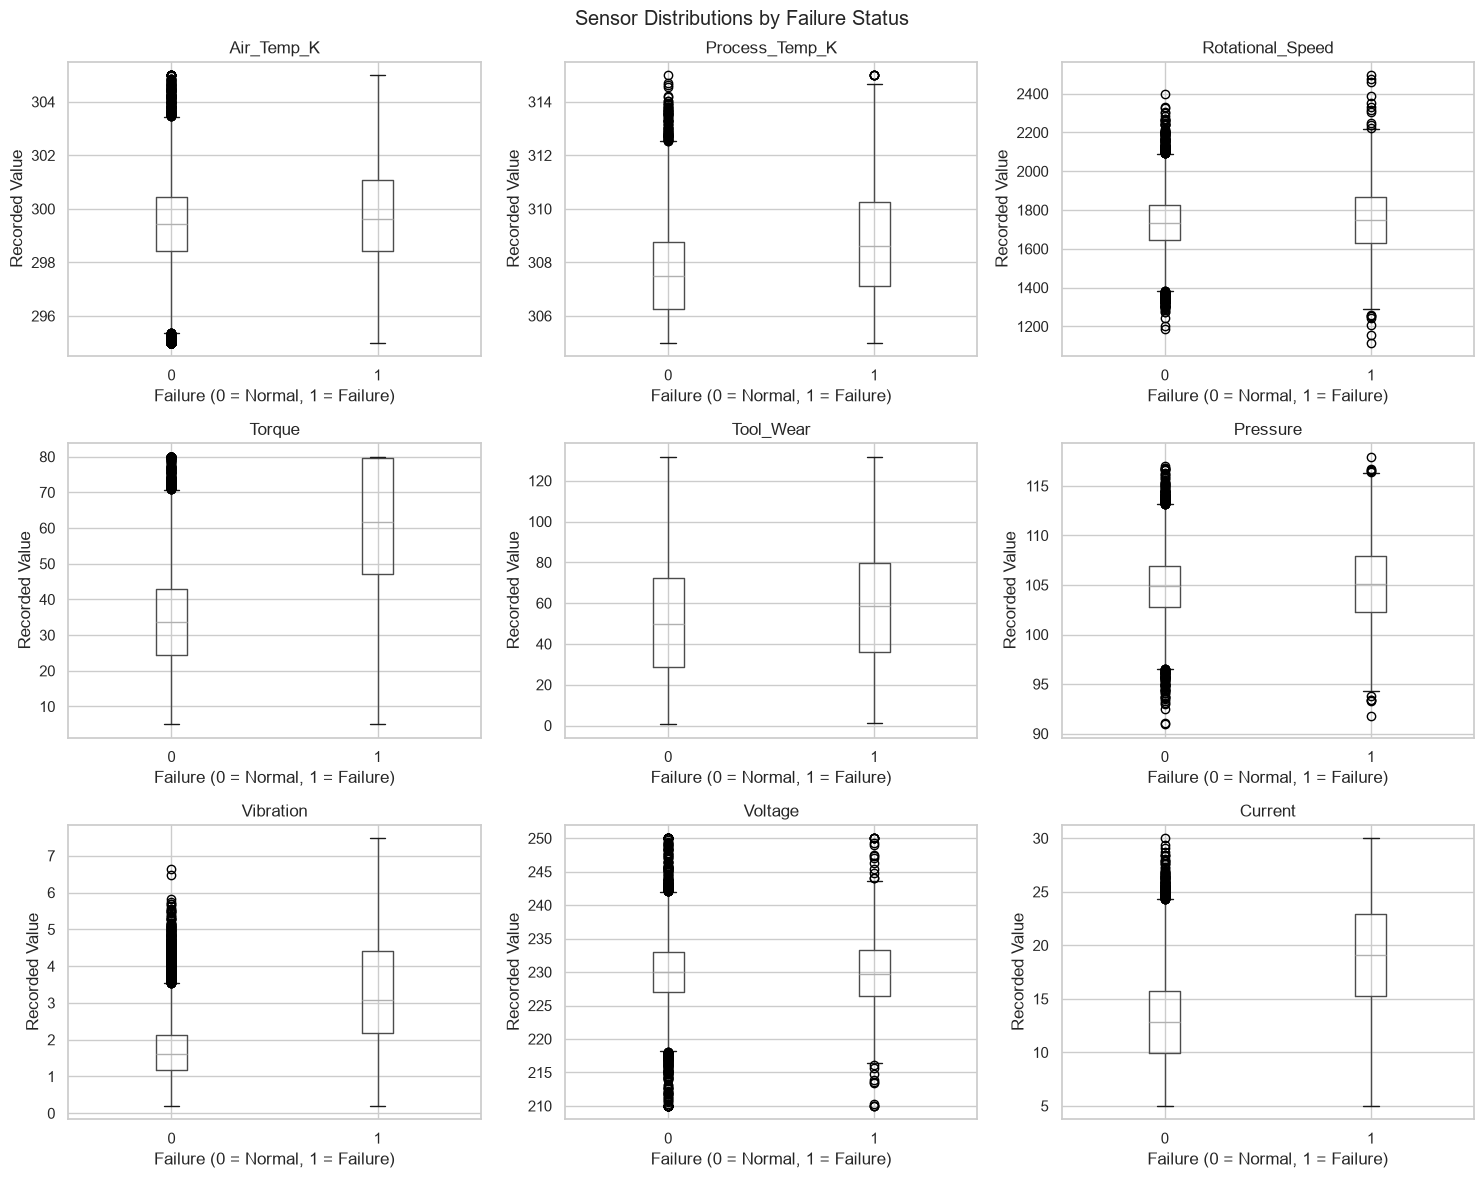

In [28]:
print("=== SENSOR VALUES BY FAILURE STATUS ===")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flat, sensor_cols):
    df.boxplot(column=col, by="failure", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Failure (0 = Normal, 1 = Failure)")
    ax.set_ylabel("Recorded Value")

plt.suptitle("Sensor Distributions by Failure Status")
plt.tight_layout()
plt.show()

In [29]:
print("=== MEDIAN AND QUANTILE COMPARISON BY FAILURE ===")

comparison = df.groupby("failure")[sensor_cols].agg(
    ["median", "mean", "max"]
)

display(comparison)

=== MEDIAN AND QUANTILE COMPARISON BY FAILURE ===


Air_Temp_K                    Process_Temp_K                     \
            median        mean    max         median        mean    max   
failure                                                                   
0           299.43  299.421859  305.0         307.49  307.580137  315.0   
1           299.61  299.797176  305.0         308.61  308.772331  315.0   

        Rotational_Speed                      Torque  ... Pressure Vibration  \
                  median         mean     max median  ...      max    median   
failure                                               ...                      
0                 1735.2  1736.042217  2397.2  33.77  ...   116.96    1.6200   
1                 1747.0  1748.220178  2496.1  61.64  ...   117.95    3.0825   

                         Voltage                   Current                   
             mean    max  median       mean    max  median       mean   max  
failure                                                                      
0        1.698944  6.641  230.03  230.05880  250.0   12.84  12.940282  30.0  
1        3.325768  7.477  229.66  229.89698  250.0   19.14  18.945962  30.0  

[2 rows x 27 columns]

In [30]:
print("=== SENSOR DISTRIBUTION BY FAILURE STATUS ===")

for col in sensor_cols:
    print(f"\n--- {col} ---")
    
    print("Normal (Failure = 0):")
    print(df.loc[df["failure"] == 0, col].describe()[["25%", "50%", "75%", "max"]])
    
    print("Failure (Failure = 1):")
    print(df.loc[df["failure"] == 1, col].describe()[["25%", "50%", "75%", "max"]])

=== SENSOR DISTRIBUTION BY FAILURE STATUS ===

--- Air_Temp_K ---
Normal (Failure = 0):
25%    298.4100
50%    299.4300
75%    300.4325
max    305.0000
Name: Air_Temp_K, dtype: float64
Failure (Failure = 1):
25%    298.42
50%    299.61
75%    301.07
max    305.00
Name: Air_Temp_K, dtype: float64

--- Process_Temp_K ---
Normal (Failure = 0):
25%    306.25
50%    307.49
75%    308.77
max    315.00
Name: Process_Temp_K, dtype: float64
Failure (Failure = 1):
25%    307.10
50%    308.61
75%    310.25
max    315.00
Name: Process_Temp_K, dtype: float64

--- Rotational_Speed ---
Normal (Failure = 0):
25%    1647.675
50%    1735.200
75%    1824.500
max    2397.200
Name: Rotational_Speed, dtype: float64
Failure (Failure = 1):
25%    1629.1
50%    1747.0
75%    1865.4
max    2496.1
Name: Rotational_Speed, dtype: float64

--- Torque ---
Normal (Failure = 0):
25%    24.29
50%    33.77
75%    42.91
max    80.00
Name: Torque, dtype: float64
Failure (Failure = 1):
25%    47.06875
50%    61.64000
75%  

### Redundant Feature Analysis

Vibration and Voltage were compared to check whether they contain duplicate information. They are **not** identical: `Vibration.equals(Voltage)` returns `False`, and all 20,250 rows differ between the two columns.

This is further confirmed by their correlations with the failure target, which diverge substantially: Vibration ≈ 0.463 versus Voltage ≈ -0.010. The two sensors capture different, largely independent information.

No redundant sensor pairs were identified in this dataset; all nine sensor variables can be retained as distinct features going into modeling.

In [31]:
print("=== REDUNDANT FEATURE CHECK ===")

print("Vibration and Voltage identical:",
      df["Vibration"].equals(df["Voltage"]))

print("Number of different rows:",
      (df["Vibration"] != df["Voltage"]).sum())

=== REDUNDANT FEATURE CHECK ===
Vibration and Voltage identical: False
Number of different rows: 20250


### Correlation Analysis

Pearson correlation was calculated between each sensor variable and the failure target to examine their linear associations.

Vibration (≈0.463), Torque (≈0.451), and Current (≈0.364) show the strongest positive linear correlations with failure — a comparatively strong signal for sensor data of this kind. Process_Temp_K (≈0.184) shows a moderate positive association.

Air_Temp_K (≈0.066), Tool_Wear (≈0.065), Rotational_Speed (≈0.024), and Pressure (≈0.017) all show weak positive correlations, close to zero. Voltage (≈-0.010) shows essentially no linear relationship with failure.

Because Pearson correlation only captures linear relationships, these results should be treated as a first-pass signal rather than a definitive ranking of feature importance. Nonlinear relationships and interactions between sensors (for example, between Torque and Rotational_Speed) may carry additional predictive information not captured here.

In [32]:
print("=== CORRELATION WITH FAILURE ===")

correlation_with_failure = (
    df[sensor_cols + ["failure"]]
    .corr()["failure"]
    .drop("failure")
    .sort_values(ascending=False)
)

display(correlation_with_failure.to_frame(name="Correlation_with_Failure"))

=== CORRELATION WITH FAILURE ===


,Correlation_with_Failure
Vibration,0.462750
Torque,0.450512
Current,0.363624
Process_Temp_K,0.184083
Air_Temp_K,0.066186
Tool_Wear,0.064573
Rotational_Speed,0.024469
Pressure,0.016654
Voltage,-0.009581


=== CORRELATION HEATMAP ===


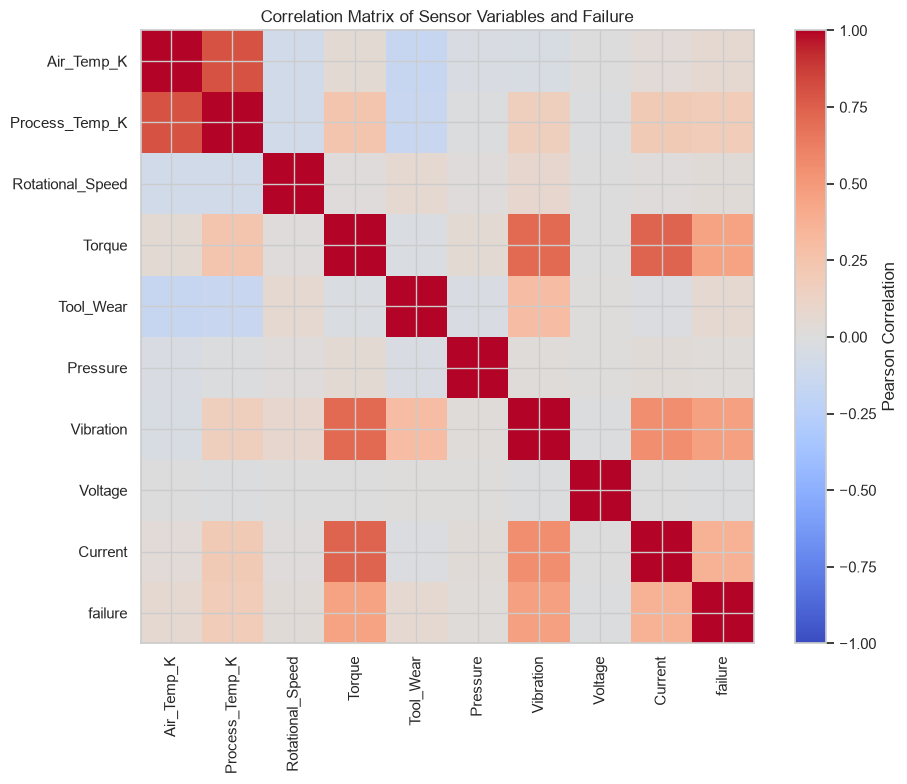

In [33]:
print("=== CORRELATION HEATMAP ===")

corr = df[sensor_cols + ["failure"]].corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix of Sensor Variables and Failure")

plt.tight_layout()
plt.show()

## EDA Findings and Conclusions

The exploratory data analysis revealed the following characteristics of the predictive-maintenance dataset.

### 1. Moderate Class Imbalance

The dataset contains 20,250 observations from 72 unique devices. Of these, 1,742 observations (8.60%) are labeled as failures — a moderate, not extreme, class imbalance. At the device level, 70 of the 72 devices (97.22%) experienced at least one recorded failure, and among those devices, failure counts range from 1 to 130 (mean ≈ 24.9, median 14.5).

This imbalance still matters for model development: accuracy alone is not an ideal primary evaluation metric. But it is far less severe than a sub-0.1% minority class would be, and standard imbalance-handling techniques (class weighting, resampling, threshold tuning) should be sufficient without needing extreme measures.

### 2. Mostly Regular, but Not Perfectly Continuous, Observations

The dataset spans 2015-01-01 to 2016-12-31 (731 unique dates) with **no missing calendar dates**. However, all 72 devices individually show at least one gap greater than one day between their own consecutive observations, with the largest device-level gap being 29 days. Observations per device range from 167 to 381.

The dataset is therefore close to a continuous daily panel overall, but should not be assumed perfectly continuous at the individual-device level.

### 3. No Zero-Inflation in Sensor Variables

None of the nine sensor variables (Air_Temp_K, Process_Temp_K, Rotational_Speed, Torque, Tool_Wear, Pressure, Vibration, Voltage, Current) contain any zero values. There is no zero-inflation to account for, and zero/non-zero comparisons are not informative for this dataset.

### 4. Mild Skewness, Modest Outlier Rates

Most sensors are close to symmetric. Vibration is the most skewed (≈1.38, moderate), followed by Torque (≈0.52), Process_Temp_K (≈0.50), and Current (≈0.44); the remaining sensors have skewness below 0.35. IQR-based outlier rates are low across the board, ranging from 0% (Tool_Wear) to about 5.2% (Vibration, the highest).

### 5. Distributional Differences by Failure Status

Torque, Vibration, and Current show the clearest separation between normal and failure observations, with medians shifting substantially higher for failures (Torque: 33.77 → 61.64; Vibration: 1.62 → 3.08; Current: 12.84 → 19.14). Process_Temp_K shows a smaller but consistent upward shift. Air_Temp_K, Pressure, Voltage, and Rotational_Speed show little to no separation between classes.

### 6. No Redundant Features

Vibration and Voltage are **not** duplicate features: they differ across all 20,250 rows and have very different correlations with failure (0.463 vs. -0.010). No redundant sensor pairs were identified.

### 7. Correlation with Failure

Vibration (0.463), Torque (0.451), and Current (0.364) show moderately strong positive linear correlations with failure. Process_Temp_K (0.184) shows a weaker but still positive association. Air_Temp_K, Tool_Wear, Rotational_Speed, and Pressure are only weakly correlated, and Voltage shows essentially no linear relationship with failure.

### Overall EDA Conclusion

The dataset presents a **moderately** imbalanced predictive-maintenance classification problem (8.60% failure rate) across 72 devices, with clean sensor data — no zero-inflation, no missing values, no duplicate rows, and no redundant features. Vibration, Torque, and Current stand out as the strongest candidate predictors, showing both clear distributional separation and moderate-to-strong linear correlation with failure. Process_Temp_K is a secondary candidate worth retaining. Voltage appears uninformative on its own but may still interact with other features.

Because failures remain a minority class (8.6%), model performance should still be evaluated using precision, recall, F1-score, PR-AUC, ROC-AUC, and the confusion matrix rather than relying on accuracy alone — though this imbalance is considerably more manageable than the near 1-in-1,000 rarity suggested in an earlier draft of this analysis, and Vibration, Torque, and Current already show a promising signal to build on.